Loaded shape: (1325, 6)
Columns: ['dlog_SOLVPN', 'dlog_COPPER', 'dlog_DXY', 'd_UST10Y', 'dlog_VIX']
Date range: 2020-10-13 00:00:00 ~ 2026-01-12 00:00:00
Usable observations after lagging: 1324
K = 5 | N_PARAMS = 6


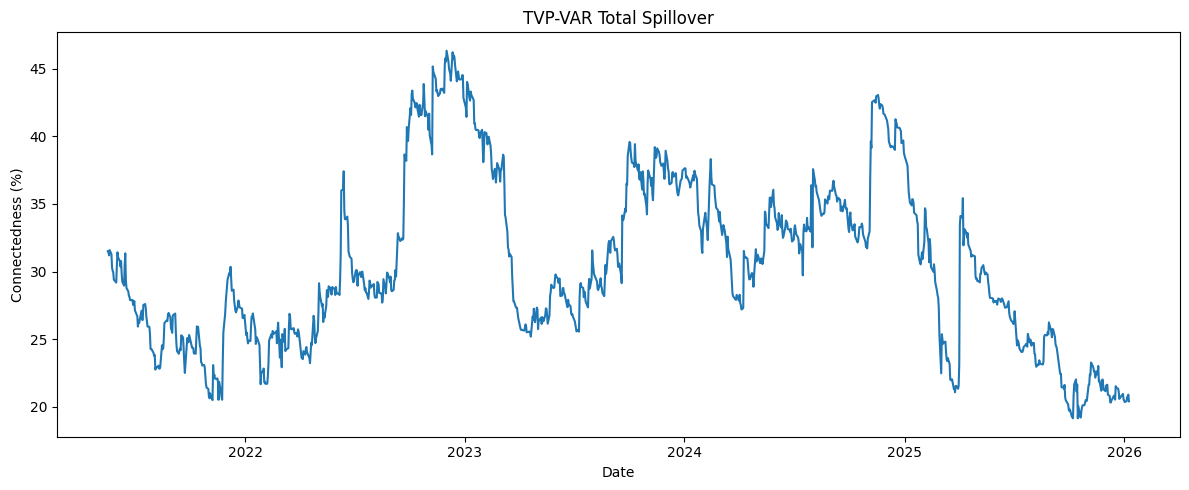

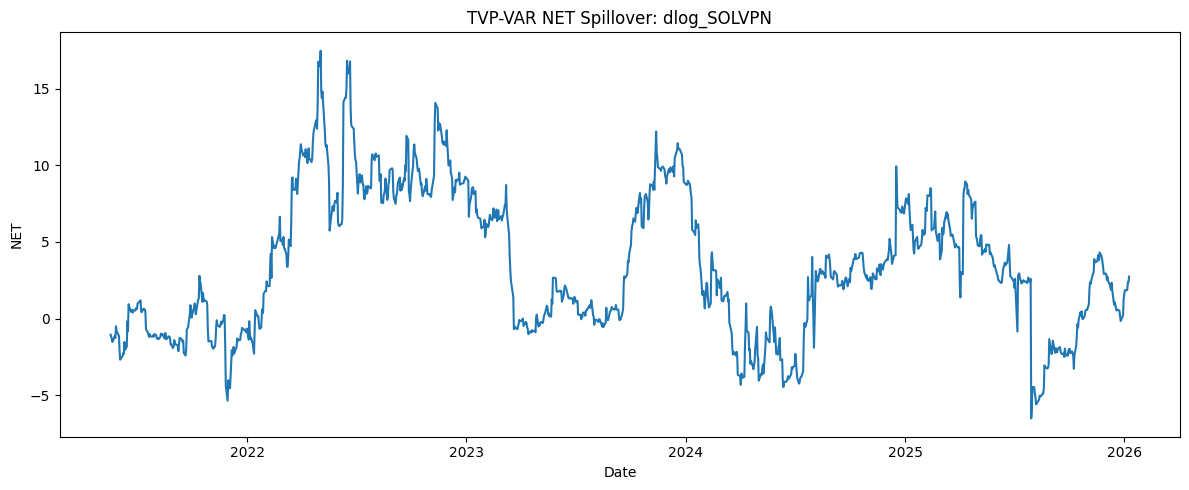

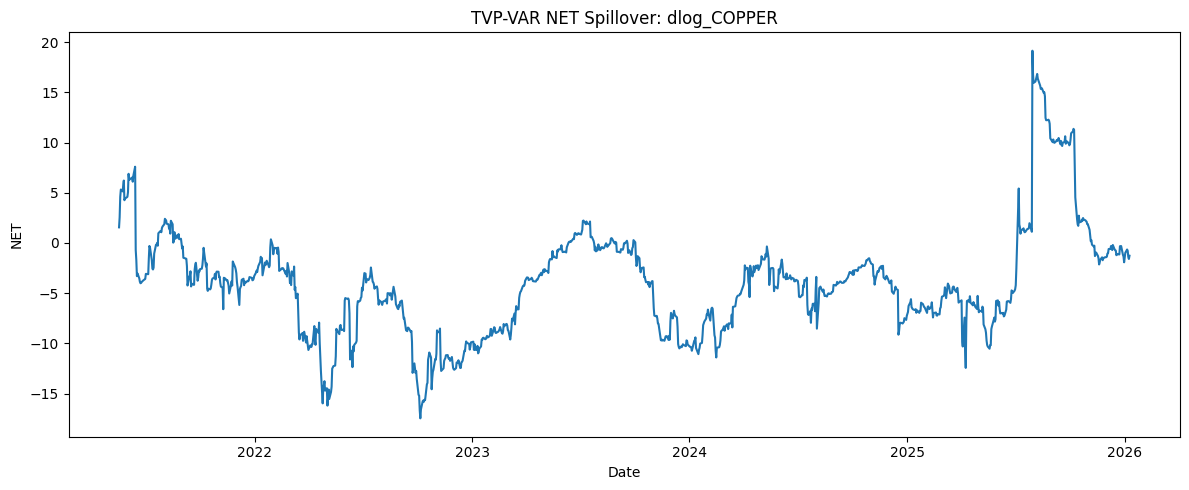

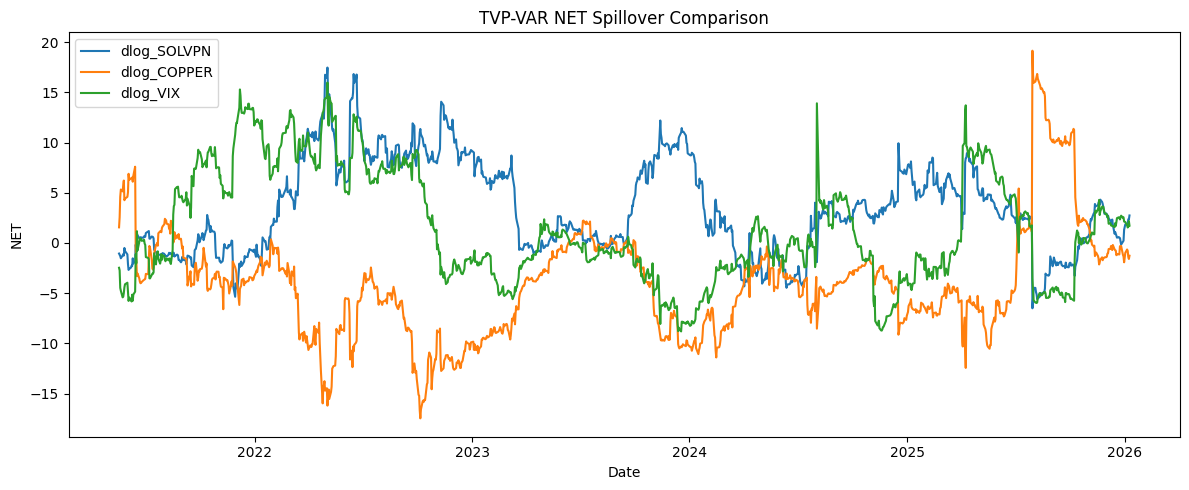

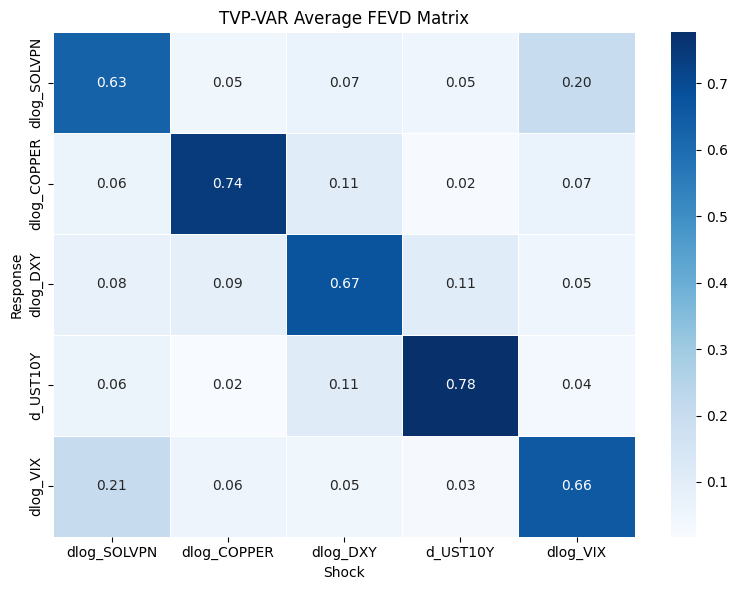

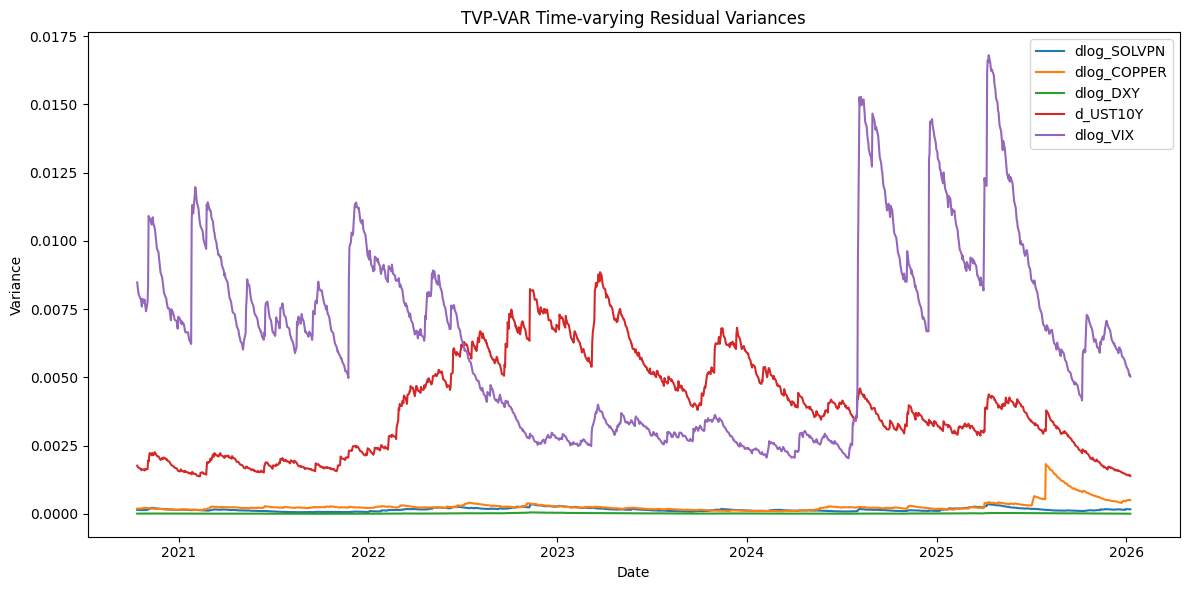


[Done] TVP-VAR connectedness completed.
Output folder: ./output_tvp_var

Total spillover summary
   Total_Mean  Total_Std  Total_Min  Total_Max  Stable_Ratio
0     30.4546     6.2744    19.1564     46.316           1.0

Variable summary
      Variable  TO_Mean   TO_Std  FROM_Mean  FROM_Std  NET_Mean  NET_Std
0  dlog_SOLVPN  40.5552  12.1743    37.1548    8.9257    3.4004   4.5809
1  dlog_COPPER  21.6440   7.9022    25.6635    7.8975   -4.0195   5.3885
2     dlog_DXY  33.3950  16.1804    32.7978   11.1126    0.5972   6.2500
3     d_UST10Y  20.9599  10.8325    22.3522   10.8047   -1.3923   2.5453
4     dlog_VIX  35.7189  10.4078    34.3046    6.7207    1.4143   5.5573

Average FEVD matrix
Shock        dlog_SOLVPN  dlog_COPPER  dlog_DXY  d_UST10Y  dlog_VIX
Response                                                           
dlog_SOLVPN       0.6285       0.0503    0.0683    0.0519    0.2010
dlog_COPPER       0.0626       0.7434    0.1056    0.0226    0.0658
dlog_DXY          0.0769       

In [2]:
# =========================================================
# TVP-VAR Connectedness for merged_var_input.csv
# - Input: ./merged_var_input.csv
# - Uses transformed/stationary columns
# - Recursive Least Squares (RLS) with forgetting factor
# - EWMA residual covariance
# - Generalized FEVD
# - Outputs: Total / TO / FROM / NET spillover over time
# - Heatmaps include numeric annotations
# =========================================================

import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from numpy.linalg import pinv, eigvals

# =========================================================
# 0. Config
# =========================================================
DATA_PATH = "./merged_var_input.csv"
OUT_DIR = "./output_tvp_var"

DATE_COL = "Date"
USE_COLS = ["dlog_SOLVPN", "dlog_COPPER", "dlog_DXY", "d_UST10Y", "dlog_VIX"]

# TVP-VAR settings
P = 1
H = 10                 # FEVD horizon
LAMBDA_BETA = 0.99     # forgetting factor for time-varying coefficients
LAMBDA_SIGMA = 0.98    # EWMA factor for residual covariance
MIN_T = 150            # warm-up period for more stable output
INIT_SCALE = 1000.0    # initial state covariance scale

HEATMAP_FMT = ".2f"

os.makedirs(OUT_DIR, exist_ok=True)

# =========================================================
# 1. Load data
# =========================================================
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"File not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

required_cols = [DATE_COL] + USE_COLS
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)
df = df[required_cols].dropna().reset_index(drop=True)

print("Loaded shape:", df.shape)
print("Columns:", USE_COLS)
print("Date range:", df[DATE_COL].min(), "~", df[DATE_COL].max())

df.to_csv(os.path.join(OUT_DIR, "tvpvar_input_clean.csv"), index=False)

# =========================================================
# 2. Helper functions
# =========================================================
def make_var_lagged(df_y: pd.DataFrame, p: int):
    """
    Create lagged matrix for VAR(p)
    Returns:
        out_df: combined dataframe with y and lags
        Y_mat: dependent matrix
        X_lag: lagged regressor matrix
        lag_cols: lag column names
    """
    x_list = []
    lag_cols = []

    for lag in range(1, p + 1):
        lagged = df_y.shift(lag)
        lagged.columns = [f"{c}_L{lag}" for c in df_y.columns]
        x_list.append(lagged)
        lag_cols.extend(lagged.columns.tolist())

    out = pd.concat([df_y] + x_list, axis=1).dropna().reset_index(drop=True)
    Y_mat = out[df_y.columns].values
    X_lag = out[lag_cols].values
    return out, Y_mat, X_lag, lag_cols


def var_companion(A_list):
    """
    A_list = [A1, ..., Ap], each (k, k)
    """
    p = len(A_list)
    k = A_list[0].shape[0]

    top = np.hstack(A_list)
    if p == 1:
        return top

    bottom = np.hstack([np.eye(k * (p - 1)), np.zeros((k * (p - 1), k))])
    return np.vstack([top, bottom])


def generalized_fevd(A_list, Sigma, H):
    """
    Pesaran-Shin generalized FEVD
    Returns row-normalized FEVD matrix
    """
    k = Sigma.shape[0]
    p = len(A_list)

    F = var_companion(A_list)
    kp = k * p if p > 1 else k
    J = np.hstack([np.eye(k), np.zeros((k, kp - k))]) if p > 1 else np.eye(k)

    Phi = []
    F_power = np.eye(kp)
    for h in range(H):
        Phi_h = J @ F_power @ J.T
        Phi.append(Phi_h)
        F_power = F_power @ F

    theta = np.zeros((k, k))
    sigma_diag = np.diag(Sigma).copy()
    sigma_diag[sigma_diag <= 1e-12] = 1e-12

    for i in range(k):
        for j in range(k):
            e_i = np.zeros((k, 1))
            e_i[i, 0] = 1.0
            e_j = np.zeros((k, 1))
            e_j[j, 0] = 1.0

            num = 0.0
            den = 0.0
            for h in range(H):
                phi_h = Phi[h]
                num += float((e_i.T @ phi_h @ Sigma @ e_j) ** 2 / sigma_diag[j])
                den += float(e_i.T @ phi_h @ Sigma @ phi_h.T @ e_i)

            theta[i, j] = num / max(den, 1e-12)

    row_sums = theta.sum(axis=1, keepdims=True)
    row_sums[row_sums <= 1e-12] = 1e-12
    theta_norm = theta / row_sums
    return theta_norm


def spillover_from_fevd(theta):
    """
    From row-normalized FEVD:
    - Total
    - TO
    - FROM
    - NET
    """
    k = theta.shape[0]
    total = 100.0 * (theta.sum() - np.trace(theta)) / k
    to_others = 100.0 * (theta.sum(axis=0) - np.diag(theta))
    from_others = 100.0 * (theta.sum(axis=1) - np.diag(theta))
    net = to_others - from_others
    return total, to_others, from_others, net


def stability_flag(A_list):
    """
    Check approximate stability using companion roots.
    For VAR stability, companion eigenvalues should be inside unit circle.
    """
    F = var_companion(A_list)
    vals = eigvals(F)
    max_abs = np.max(np.abs(vals))
    stable = bool(max_abs < 1.0)
    return stable, float(max_abs)


# =========================================================
# 3. Prepare lagged data
# =========================================================
base_df, Y_mat, X_lag, lag_cols = make_var_lagged(df[USE_COLS], P)
dates2 = df[DATE_COL].iloc[base_df.index].reset_index(drop=True)

# add intercept
X_full = np.column_stack([np.ones(len(X_lag)), X_lag])

T2 = len(Y_mat)
K = len(USE_COLS)
N_PARAMS = X_full.shape[1]

print("Usable observations after lagging:", T2)
print("K =", K, "| N_PARAMS =", N_PARAMS)

if MIN_T >= T2:
    raise ValueError(f"MIN_T={MIN_T} is too large for available observations={T2}")

# =========================================================
# 4. Initialize using OLS on initial sample
# =========================================================
init_n = max(MIN_T, N_PARAMS + 20)
init_n = min(init_n, T2 - 1)

X_init = X_full[:init_n]
Y_init = Y_mat[:init_n]

betas_t = np.zeros((T2, K, N_PARAMS))
resids_t = np.zeros((T2, K))

for eq in range(K):
    y0 = Y_init[:, eq]
    beta0 = pinv(X_init.T @ X_init) @ (X_init.T @ y0)

    P_prev = np.eye(N_PARAMS) * INIT_SCALE
    beta_prev = beta0.copy()

    for t in range(T2):
        x_t = X_full[t].reshape(-1, 1)
        y_t = Y_mat[t, eq]

        y_hat = float(beta_prev @ x_t[:, 0])
        err = y_t - y_hat

        denom = LAMBDA_BETA + float(x_t.T @ P_prev @ x_t)
        if denom <= 1e-12:
            denom = 1e-12

        K_t = (P_prev @ x_t) / denom
        beta_new = beta_prev + (K_t[:, 0] * err)
        P_new = (P_prev - K_t @ x_t.T @ P_prev) / LAMBDA_BETA

        betas_t[t, eq, :] = beta_new
        resids_t[t, eq] = err

        beta_prev = beta_new
        P_prev = P_new

# save coefficients (long format)
coef_rows = []
for t in range(T2):
    for eq_idx, eq_name in enumerate(USE_COLS):
        row = {
            "Date": dates2.iloc[t],
            "Equation": eq_name,
            "Intercept": float(betas_t[t, eq_idx, 0])
        }
        coef_no_const = betas_t[t, eq_idx, 1:]
        for lag in range(P):
            block = coef_no_const[lag*K:(lag+1)*K]
            for j, src in enumerate(USE_COLS):
                row[f"L{lag+1}_{src}"] = float(block[j])
        coef_rows.append(row)

coef_df = pd.DataFrame(coef_rows)
coef_df.to_csv(os.path.join(OUT_DIR, "tvpvar_coefficients_long.csv"), index=False)

# =========================================================
# 5. Time-varying residual covariance via EWMA
# =========================================================
Sigma_t = np.zeros((T2, K, K))

Sigma_prev = np.cov(resids_t[:init_n].T)
Sigma_prev = (Sigma_prev + Sigma_prev.T) / 2
diag_prev = np.diag(Sigma_prev).copy()
diag_prev[diag_prev < 1e-8] = 1e-8
np.fill_diagonal(Sigma_prev, diag_prev)

for t in range(T2):
    e_t = resids_t[t].reshape(-1, 1)
    Sigma_new = LAMBDA_SIGMA * Sigma_prev + (1.0 - LAMBDA_SIGMA) * (e_t @ e_t.T)
    Sigma_new = (Sigma_new + Sigma_new.T) / 2

    diag_new = np.diag(Sigma_new).copy()
    diag_new[diag_new < 1e-8] = 1e-8
    np.fill_diagonal(Sigma_new, diag_new)

    Sigma_t[t] = Sigma_new
    Sigma_prev = Sigma_new

# save conditional variance diagonals
sigma_diag_rows = []
for t in range(T2):
    row = {"Date": dates2.iloc[t]}
    for i, v in enumerate(USE_COLS):
        row[f"Var_{v}"] = float(Sigma_t[t, i, i])
    sigma_diag_rows.append(row)

sigma_diag_df = pd.DataFrame(sigma_diag_rows)
sigma_diag_df.to_csv(os.path.join(OUT_DIR, "tvpvar_conditional_variances.csv"), index=False)

# =========================================================
# 6. Time-varying FEVD / Connectedness
# =========================================================
conn_rows = []
pairwise_rows = []
stability_rows = []

for t in range(T2):
    if t < MIN_T:
        continue

    coef_block = betas_t[t, :, 1:]
    A_list = []
    for lag in range(P):
        A_l = coef_block[:, lag*K:(lag+1)*K]
        A_list.append(A_l)

    Sigma = Sigma_t[t]

    stable, max_abs_root = stability_flag(A_list)
    stability_rows.append({
        "Date": dates2.iloc[t],
        "Stable": stable,
        "MaxAbsRoot": max_abs_root
    })

    theta = generalized_fevd(A_list, Sigma, H)
    total, to_, from_, net_ = spillover_from_fevd(theta)

    row = {
        "Date": dates2.iloc[t],
        "Total_Spillover": float(total),
        "Stable": stable,
        "MaxAbsRoot": float(max_abs_root)
    }

    for i, var in enumerate(USE_COLS):
        row[f"{var}_TO"] = float(to_[i])
        row[f"{var}_FROM"] = float(from_[i])
        row[f"{var}_NET"] = float(net_[i])

    conn_rows.append(row)

    for i, response in enumerate(USE_COLS):
        for j, shock in enumerate(USE_COLS):
            pairwise_rows.append({
                "Date": dates2.iloc[t],
                "Response": response,
                "Shock": shock,
                "FEVD": float(theta[i, j])
            })

conn_df = pd.DataFrame(conn_rows)
pairwise_df = pd.DataFrame(pairwise_rows)
stability_df = pd.DataFrame(stability_rows)

conn_df.to_csv(os.path.join(OUT_DIR, "tvpvar_connectedness.csv"), index=False)
pairwise_df.to_csv(os.path.join(OUT_DIR, "tvpvar_pairwise_fevd.csv"), index=False)
stability_df.to_csv(os.path.join(OUT_DIR, "tvpvar_stability.csv"), index=False)

# =========================================================
# 7. Average FEVD matrix
# =========================================================
avg_fevd = (
    pairwise_df.groupby(["Response", "Shock"])["FEVD"]
    .mean()
    .unstack()
    .reindex(index=USE_COLS, columns=USE_COLS)
)
avg_fevd.to_csv(os.path.join(OUT_DIR, "tvpvar_average_fevd_matrix.csv"))

summary_rows = []
for var in USE_COLS:
    summary_rows.append({
        "Variable": var,
        "TO_Mean": conn_df[f"{var}_TO"].mean(),
        "TO_Std": conn_df[f"{var}_TO"].std(),
        "FROM_Mean": conn_df[f"{var}_FROM"].mean(),
        "FROM_Std": conn_df[f"{var}_FROM"].std(),
        "NET_Mean": conn_df[f"{var}_NET"].mean(),
        "NET_Std": conn_df[f"{var}_NET"].std(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(OUT_DIR, "tvpvar_summary_by_variable.csv"), index=False)

total_summary = pd.DataFrame([{
    "Total_Mean": conn_df["Total_Spillover"].mean(),
    "Total_Std": conn_df["Total_Spillover"].std(),
    "Total_Min": conn_df["Total_Spillover"].min(),
    "Total_Max": conn_df["Total_Spillover"].max(),
    "Stable_Ratio": conn_df["Stable"].mean()
}])
total_summary.to_csv(os.path.join(OUT_DIR, "tvpvar_total_spillover_summary.csv"), index=False)

# =========================================================
# 8. Metadata
# =========================================================
meta = {
    "model": "TVP-VAR Connectedness (RLS + EWMA baseline)",
    "data_path": DATA_PATH,
    "date_col": DATE_COL,
    "use_cols": USE_COLS,
    "lag_order": P,
    "fevd_horizon": H,
    "lambda_beta": LAMBDA_BETA,
    "lambda_sigma": LAMBDA_SIGMA,
    "min_t": MIN_T,
    "init_scale": INIT_SCALE,
    "n_obs_input": int(len(df)),
    "n_obs_after_lag": int(T2),
}
with open(os.path.join(OUT_DIR, "metadata.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2, default=str)

# =========================================================
# 9. Plots
# =========================================================
plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(conn_df["Date"]), conn_df["Total_Spillover"])
plt.title("TVP-VAR Total Spillover")
plt.xlabel("Date")
plt.ylabel("Connectedness (%)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "tvpvar_total_spillover.png"), dpi=300)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(conn_df["Date"]), conn_df["dlog_SOLVPN_NET"])
plt.title("TVP-VAR NET Spillover: dlog_SOLVPN")
plt.xlabel("Date")
plt.ylabel("NET")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "tvpvar_SOLVPN_net.png"), dpi=300)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(conn_df["Date"]), conn_df["dlog_COPPER_NET"])
plt.title("TVP-VAR NET Spillover: dlog_COPPER")
plt.xlabel("Date")
plt.ylabel("NET")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "tvpvar_COPPER_net.png"), dpi=300)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(conn_df["Date"]), conn_df["dlog_SOLVPN_NET"], label="dlog_SOLVPN")
plt.plot(pd.to_datetime(conn_df["Date"]), conn_df["dlog_COPPER_NET"], label="dlog_COPPER")
plt.plot(pd.to_datetime(conn_df["Date"]), conn_df["dlog_VIX_NET"], label="dlog_VIX")
plt.title("TVP-VAR NET Spillover Comparison")
plt.xlabel("Date")
plt.ylabel("NET")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "tvpvar_NET_comparison.png"), dpi=300)
plt.show()

# Heatmap with numeric annotations
plt.figure(figsize=(8, 6))
sns.heatmap(
    avg_fevd,
    annot=True,
    fmt=HEATMAP_FMT,
    cmap="Blues",
    linewidths=0.5,
    cbar=True
)
plt.title("TVP-VAR Average FEVD Matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "tvpvar_average_fevd_heatmap.png"), dpi=300)
plt.show()

plt.figure(figsize=(12, 6))
for v in USE_COLS:
    plt.plot(pd.to_datetime(sigma_diag_df["Date"]), sigma_diag_df[f"Var_{v}"], label=v)
plt.title("TVP-VAR Time-varying Residual Variances")
plt.xlabel("Date")
plt.ylabel("Variance")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "tvpvar_conditional_variances.png"), dpi=300)
plt.show()

# =========================================================
# 10. Print summary
# =========================================================
print("\n[Done] TVP-VAR connectedness completed.")
print("Output folder:", OUT_DIR)

print("\nTotal spillover summary")
print(total_summary.round(4))

print("\nVariable summary")
print(summary_df.round(4))

print("\nAverage FEVD matrix")
print(avg_fevd.round(4))